In [1]:

import numpy as np
import matplotlib.pyplot as plt

# Set environment variables
import os


os.environ["SCAL_TYPE"] = "complex"
os.environ["PRECISION"] = "single"
os.environ["MY_NUMBA_TARGET"] = "numba"

# Add cle_fun to PYTHON_PATH
import sys
sys.path.append("../../clonscal_bak")

In [2]:
import numpy as np
from simulation.config import Config
from simulation.cl_simulation import ComplexLangevinSimulation
from src.obs_kernels import (
    n_moment_kernel, 
    dse_n_moment_kernel,
    abs_drift
)
from tqdm import tqdm
from simulation.gpu_handler import GPU_handler
from src.numba_target import use_cuda
import src.scal as scal
from src.utils import (
    update_histogram_complex, 
    update_histogram_real,
    gaussian_modified_density_drift_kernel, 
    noise_kernel_rotated,
    calculate_stats_complex
)

from src.numba_target import my_act_parallel_loop
from numba import cuda

Using single precision
Using C^1
Using Numba


define a configuration with desired parameters. see simulation.config.py for defaults. Based on the config, define a simulation object

In [3]:
config = Config(dims = [1], sigma=1, interaction=1, trajs = 2, steps = int(1e4), dt = 1e-3)
sim = ComplexLangevinSimulation(config)

Register observables into the object. This defines ObservableTracker instances

In [4]:
sim.register_observable('1_moment', obs_kernel=n_moment_kernel, const_param={"order" : 1},  langevin_history=True, thermal_time=1, auto_corr=1.0)
sim.register_observable('2_moment', obs_kernel=n_moment_kernel, const_param={"order" : 2},  langevin_history=True, thermal_time=1, auto_corr=1.0)

These can not be addressed via

In [5]:
sim.trackers

{'1_moment': <simulation.observables.ObservableTracker at 0x110933e20>,
 '2_moment': <simulation.observables.ObservableTracker at 0x105aa7370>}

The trackers are independent from each other. The observable carries information about all the trajectories, see shape of the arrays

In [6]:
sim.trackers["1_moment"].__dict__

{'obs_name': '1_moment',
 'shape': (2,),
 'obs_kernel': CPUDispatcher(<function n_moment_kernel at 0x1115e9360>),
 'langevin_history': True,
 'const_param': {'order': 1},
 'init_history_size': 10000,
 'thermal_time': 1,
 'auto_corr': 1.0,
 'maximal_lt': 100,
 'order': 1,
 '_sim_instance': <simulation.cl_simulation.ComplexLangevinSimulation at 0x110933ee0>,
 'equilibrated_trajs': array([False, False]),
 'meas_time': array([-1., -1.], dtype=float32),
 'result': array([0.+0.j, 0.+0.j], dtype=complex64),
 'history_result': array([0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
       dtype=complex64),
 'history_counter': array([0, 0, 0, ..., 0, 0, 0], dtype=int32),
 'history_meas_times': array([0., 0., 0., ..., 0., 0., 0.], dtype=float32),
 'kernel_bridge': <src.utils.KernelBridge at 0x110933bb0>,
 'stats': <src.utils.RollingStats at 0x112fa0c40>,
 'rolling_mean': array([0.+0.j, 0.+0.j], dtype=complex64),
 'rolling_sqr_mean_real': array([0., 0.], dtype=float32),
 'rolling_sqr_mean_im

Once a simulation steps is performed

In [7]:
sim.step()

the global degree of freedom sim.phi is updated according to the langevin equation. It stores the values for all the trajectories. 

In [8]:
sim.phi0

array([-0.00625094+0.j, -0.02095349+0.j], dtype=complex64)

After a step, we have to decide whether observables are to be calculated, depending on tracker.thermal_time and tracker.auto_corr.  
Every trajectory is associated with a boolean that allows or blocks calculation. These are set to False in the beginning

In [9]:
sim.trackers["1_moment"].equilibrated_trajs

array([False, False])

We could call tracker.compute(), but all trajectories will be ignored. Their result is unchanged (zero)

In [10]:
sim.trackers["1_moment"].compute()
print(sim.trackers["1_moment"].result)
print(sim.trackers["1_moment"].counter)

[0.+0.j 0.+0.j]
[0 0]


only after a certain number of steps will the trajs be allowed to be observed. To (un)block the trajs, we call tracker.mark_equilibrated_trajs

In [11]:
for _ in tqdm(range(int(5e3))):
    sim.step()
    for name, tr in sim.trackers.items():
        tr.mark_equilibrated_trajs()

100%|██████████| 5000/5000 [00:00<00:00, 10002.60it/s]


In [12]:
sim.trackers["1_moment"].equilibrated_trajs

array([ True,  True])

After computation, the result is stored in a buffer and the rolling stats are updated.

In [13]:
sim.trackers["1_moment"].compute()
sim.trackers["1_moment"].mark_equilibrated_trajs()
sim.trackers["1_moment"].equilibrated_trajs
print(f"Result buffer: {sim.trackers['1_moment'].result}")
print(f"Counter: {sim.trackers['1_moment'].counter}")
print(f"Rolling mean: {sim.trackers['1_moment'].rolling_mean}")
print(f"Rolling sq mean: {sim.trackers['1_moment'].rolling_sqr_mean_real}")
print()

Result buffer: [ 0.07491874+0.0000000e+00j -0.10328496+1.2648759e-17j]
Counter: [1 1]
Rolling mean: [ 0.07491874+0.0000000e+00j -0.10328496+1.2648759e-17j]
Rolling sq mean: [0.00561282 0.01066778]



The full loop looks someting like this

In [14]:
for _ in tqdm(range(sim.steps)):
    sim.step()
    for name, tr in sim.trackers.items():
        tr.mark_equilibrated_trajs()
        tr.compute()

print(f"Result buffer: {sim.trackers['1_moment'].result}")
print(f"Counter: {sim.trackers['1_moment'].counter}")
print(f"Rolling mean: {sim.trackers['1_moment'].rolling_mean}")
print(f"Rolling sq mean: {sim.trackers['1_moment'].rolling_sqr_mean_real}")
print()

100%|██████████| 10000/10000 [00:01<00:00, 6928.79it/s]

Result buffer: [0.05985037+0.j 0.3740821 +0.j]
Counter: [10 10]
Rolling mean: [-0.8103524+2.6990541e-16j  0.6898813+1.7983425e-16j]
Rolling sq mean: [2.1031637 2.3647091]



To combine the rolling stats over different observables, call sim.finish()

In [15]:
sim.finish()
sim.trackers["1_moment"].rolling_mean

(-0.12047106+4.4973966e-16j)

from here stats can be calculated using utils.calculate_stats_complex

In [16]:
from src.utils import calculate_stats_complex
rolling_mean = sim.trackers["1_moment"].rolling_mean
rolling_sqr_mean_real = sim.trackers["1_moment"].rolling_sqr_mean_real
rolling_sqr_mean_imag = sim.trackers["1_moment"].rolling_sqr_mean_imag
counter = sim.trackers["1_moment"].counter
mean, sem_real, sem_imag = calculate_stats_complex(rolling_mean, rolling_sqr_mean_real, rolling_sqr_mean_imag, counter)

print(f"First moment: {np.round(mean, 5)} pm {np.round(sem_real, 5)}")

First moment: (-0.00602+0j) pm 0.10568


The code is optimized for parallel execution of multiple trajectories

In [17]:
config = Config(dims = [1], sigma=1, interaction=1, trajs = int(1e4), steps = int(1e4), dt = 1e-3)
sim = ComplexLangevinSimulation(config)

sim.register_observable('1_moment', obs_kernel=n_moment_kernel, const_param={"order" : 1},  langevin_history=True, thermal_time=2, auto_corr=1.0)
sim.register_observable('2_moment', obs_kernel=n_moment_kernel, const_param={"order" : 2},  langevin_history=True, thermal_time=2, auto_corr=1.0)

for _ in tqdm(range(sim.steps)):
    sim.step()
    for name, tr in sim.trackers.items():
        tr.mark_equilibrated_trajs()
        tr.compute()
sim.finish()

100%|██████████| 10000/10000 [00:03<00:00, 3314.14it/s]


In [18]:
# scipy routines
import numpy as np
from scipy.integrate import quad
from numba import jit

def n_moment(x, order):
    return x**order

# define rho and R
@jit
def action(x, sigma, lamb): return sigma/2*x**2+lamb/4*x**4

@jit
def rho(x, sigma, lamb): return np.exp(-action(x, sigma, lamb))

# define partition sums
def z_rho(sigma, lamb): 
    real_part = quad(lambda x: np.real(rho(x, sigma, lamb)), -np.inf, np.inf)[0]
    imag_part = quad(lambda x: np.imag(rho(x, sigma, lamb)), -np.inf, np.inf)[0]
    return real_part+1j*imag_part


# define exp val of n_moment wrt rho
@np.vectorize
def n_moment_rho(order, sigma, lamb):
    real_part = quad(lambda x: np.real(rho(x, sigma, lamb)*n_moment(x, order)), 
                     -np.inf, np.inf)[0]
    imag_part = quad(lambda x: np.imag(rho(x, sigma, lamb)*n_moment(x, order)), 
                     -np.inf, np.inf)[0]
    out = real_part + 1j*imag_part
    return out / z_rho(sigma, lamb)

In [19]:
sim.trackers["1_moment"].rolling_mean

(176.42322+2.7519792e-12j)

In [20]:
rolling_mean = sim.trackers["1_moment"].rolling_mean
rolling_sqr_mean_real = sim.trackers["1_moment"].rolling_sqr_mean_real
rolling_sqr_mean_imag = sim.trackers["1_moment"].rolling_sqr_mean_imag
counter = sim.trackers["1_moment"].counter
mean, sem_real, sem_imag = calculate_stats_complex(rolling_mean, rolling_sqr_mean_real, rolling_sqr_mean_imag, counter)

print(f"First moment: in [{np.round(mean-sem_real, 5)}; {np.round(mean+sem_real, 5)}]")
print(f"scipy: {n_moment_rho(1, sim.sigma, sim.interaction)}")

First moment: in [(-0.00022+0j); (0.00463+0j)]
scipy: 0j


In [21]:
rolling_mean = sim.trackers["2_moment"].rolling_mean
rolling_sqr_mean_real = sim.trackers["2_moment"].rolling_sqr_mean_real
rolling_sqr_mean_imag = sim.trackers["2_moment"].rolling_sqr_mean_imag
counter = sim.trackers["2_moment"].counter
mean, sem_real, sem_imag = calculate_stats_complex(rolling_mean, rolling_sqr_mean_real, rolling_sqr_mean_imag, counter)

print(f"Second moment: in[{np.round(mean-sem_real, 5).real}; {np.round(mean+sem_real, 5).real}] {np.round(sem_real/mean, 4).real*100}% relative error")
print(f"scipy: {n_moment_rho(2, sim.sigma, sim.interaction)}")

Second moment: in[0.46831; 0.47231] 0.43% relative error
scipy: (0.4679199169736833+0j)


In [1]:

import numpy as np
import matplotlib.pyplot as plt

# Set environment variables
import os


os.environ["SCAL_TYPE"] = "complex"
os.environ["PRECISION"] = "single"
os.environ["MY_NUMBA_TARGET"] = "numba"

# Add cle_fun to PYTHON_PATH
import sys
sys.path.append("../../clonscal_bak")

import numpy as np
from simulation.config import Config
from simulation.cl_simulation import ComplexLangevinSimulation
from src.obs_kernels import (
    n_moment_kernel, 
    dse_n_moment_kernel,
    abs_drift
)
from tqdm import tqdm
from simulation.gpu_handler import GPU_handler
from src.numba_target import use_cuda
import src.scal as scal
from src.utils import (
    update_histogram_complex, 
    update_histogram_real,
    gaussian_modified_density_drift_kernel, 
    noise_kernel_rotated,
    calculate_stats_complex
)

from src.numba_target import my_act_parallel_loop
from numba import cuda

Using single precision
Using C^1
Using Numba


# Killing trajs
There mght be reasons to not consider single trajectories (they wandered off, ...)  
By changing sim.alive, some trajs will be ignored 

In [2]:
config = Config(dims = [1], sigma=1, interaction=1, trajs = 2, steps = int(1e4), dt = 1e-3)
sim = ComplexLangevinSimulation(config)

By changing the alive array manually, the dea traj is ignored. Field and eta are not updated.

In [3]:
sim.step()
sim.alive[0] = False
for _ in range(5):
    sim.step()
    print(f"Field: {sim.phi0}")
    print(f"Noise: {sim.eta}")
    print()


Field: [0.00206812+0.j 0.10434231+0.j]
Noise: [0.06539975+0.j 1.4232682 +0.j]

Field: [0.00206812+0.j 0.12453187+0.j]
Noise: [0.06539975+0.j 0.64178514+0.j]

Field: [0.00206812+0.j 0.11913297+0.j]
Noise: [ 0.06539975+0.j -0.16672894+0.j]

Field: [0.00206812+0.j 0.1743359 +0.j]
Noise: [0.06539975+0.j 1.7494906 +0.j]

Field: [0.00206812+0.j 0.18130928+0.j]
Noise: [0.06539975+0.j 0.22619824+0.j]



Based on a condition we can automatically kill trajectories by calling sim.kill_trajs(). per default, the condition is a dS_max > 1e4
simulate runaway and read out max drift. It is huge

In [4]:
sim = ComplexLangevinSimulation(config)

sim.step()
sim.phi0[0] = 50
sim.step()

# the drift of the first traj is huge
print(f"Drift mag: {sim.dS_max}")

Drift mag: [1.2505000e+05 5.0737333e-02]


execute trajs based on conditon dS_max > 1e4

In [5]:
sim.kill_trajs()
sim.alive

array([False,  True])

### Observables are only calculated for alive trajs

In [6]:
sim = ComplexLangevinSimulation(config)

sim.register_observable('1_moment', obs_kernel=n_moment_kernel, const_param={"order" : 1},  langevin_history=True, thermal_time=0, auto_corr=0)

In [7]:
sim.step()
sim.trackers["1_moment"].mark_equilibrated_trajs()
print(f"Both trajs are ready to be calculated: {sim.trackers['1_moment'].equilibrated_trajs}")

Both trajs are ready to be calculated: [ True  True]


simulate runaway. This kills the traj

In [8]:
sim.phi0[0] = 50
sim.step()
sim.kill_trajs()

print(f"Trajs alive: {sim.alive}")
sim.trackers["1_moment"].mark_equilibrated_trajs()
print(f"Ready to calculate: {sim.trackers['1_moment'].equilibrated_trajs}")

Trajs alive: [False  True]
Ready to calculate: [False  True]


I have observed runaways in the regime of broken symmetry

Without killing the trajs, the drift will of some trajs will be huge and the adaptive step tiny

Text(0, 0.5, 'Minimal update step')

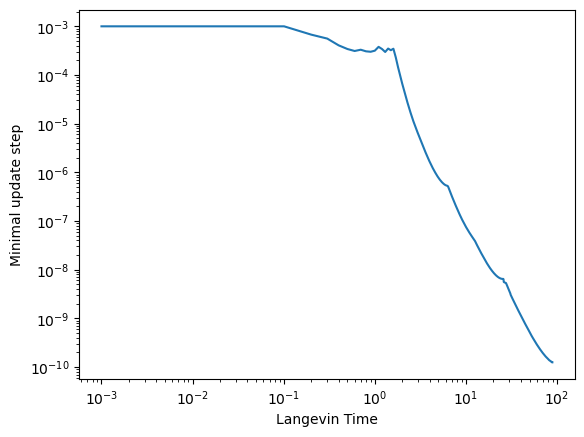

In [26]:
config = Config(dims = [1], sigma=-1+1j, interaction=1, trajs = int(1e4), steps = int(1e5), dt = 1e-3, ada_step = True)
sim = ComplexLangevinSimulation(config)

sim.register_observable('1_moment', obs_kernel=n_moment_kernel, const_param={"order" : 1},  langevin_history=True, thermal_time=0, auto_corr=0)

ada = []
max_dr = []
lt = []

for idx in range(sim.steps):
    sim.step()
    if idx%100 == 0:
        idx_max = np.argmax(sim.dS_max.max())
        ada.append(sim.ada.min()*sim.dt)
        max_dr.append(sim.dS_max.max())
        lt.append(sim.langevin_time[idx_max])
        # print(f"maximal drift: {sim.dS_max.max()} minimal ada_step: {sim.ada.min()}" )
import matplotlib.pyplot as plt
plt.plot(lt, ada)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Langevin Time")
plt.ylabel("Minimal update step")

By killing trajs, the minimal update step is bound from below

Text(0, 0.5, 'Minimal update step')

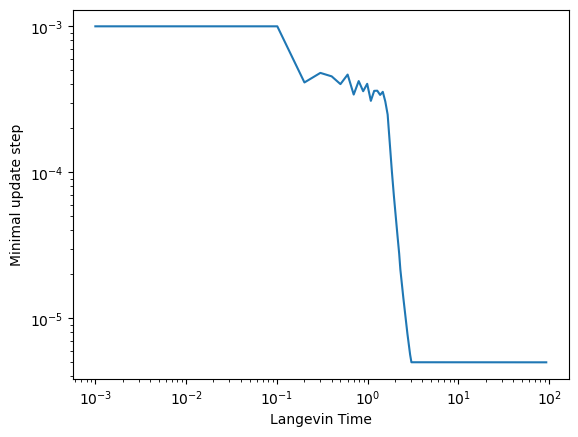

In [27]:
config = Config(dims = [1], sigma=-1+1j, interaction=1, trajs = int(1e4), steps = int(1e5), dt = 1e-3, ada_step = True)
sim = ComplexLangevinSimulation(config)

sim.register_observable('1_moment', obs_kernel=n_moment_kernel, const_param={"order" : 1},  langevin_history=True, thermal_time=0, auto_corr=0)

ada = []
max_dr = []
lt = []

for idx in range(sim.steps):
    sim.step()
    sim.kill_trajs()
    if idx%100 == 0:
        idx_max = np.argmax(sim.dS_max.max())
        ada.append(sim.ada.min()*sim.dt)
        max_dr.append(sim.dS_max.max())
        lt.append(sim.langevin_time[idx_max])
        # print(f"maximal drift: {sim.dS_max.max()} minimal ada_step: {sim.ada.min()}" )
import matplotlib.pyplot as plt
plt.plot(lt, ada)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Langevin Time")
plt.ylabel("Minimal update step")